## Modeling

## 1. Objective
The objective of this notebook is to train and evaluate machine learning models for predicting customer churn.

This notebook will:
- Load the processed feature matrices (`X_tree`, `X_linear`) and target labels (`y`)
- Split the dataset into train and test sets
- Train baseline and more advanced models
- Evaluate using appropriate classification metrics (ROC-AUC, PR-AUC, confusion matrix)
- Tune a decision threshold to balance precision and recall
- Identify important features driving churn predictions


## 2. Imports and Data Loading

We load the feature sets created during feature engineering:
- `X_linear`: scaled numeric features + reduced multicollinearity (best for linear models)
- `X_tree`: one-hot encoded features without scaling (best for tree-based models)
- `y`: binary target label (1 = churn, 0 = no churn)


In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)


In [19]:
X_tree = pd.read_csv("../data/processed/X_tree.csv")
X_linear = pd.read_csv("../data/processed/X_linear.csv")
y = pd.read_csv("../data/processed/y.csv").squeeze()

X_tree.shape, X_linear.shape, y.shape


((7043, 25), (7043, 24), (7043,))

In [20]:
# 1) Ensure target is not accidentally included as a feature
for name, X in [("X_tree", X_tree), ("X_linear", X_linear)]:
    if "Churn" in X.columns:
        print(f"[LEAK] {name} contains 'Churn' column. Dropping it.")
        X.drop(columns=["Churn"], inplace=True)

# 2) Check for exact copies of the target (feature == y for all rows)
def find_exact_leaks(X, y):
    leaks = []
    y_arr = np.asarray(y).astype(int)
    for col in X.columns:
        s = X[col]
        # Convert bool to int for comparison
        if s.dtype == bool:
            s = s.astype(int)
        # Only compare if the column is binary-like
        if set(pd.unique(s)) <= {0, 1}:
            if np.array_equal(s.to_numpy().astype(int), y_arr):
                leaks.append(col)
    return leaks

leaks_tree = find_exact_leaks(X_tree, y)
leaks_lin  = find_exact_leaks(X_linear, y)

print("Exact leakage columns in X_tree:", leaks_tree)
print("Exact leakage columns in X_linear:", leaks_lin)


Exact leakage columns in X_tree: ['Churn_Yes']
Exact leakage columns in X_linear: ['Churn_Yes']


In [21]:
X_tree = X_tree.drop(columns=["Churn_Yes"], errors="ignore")
X_linear = X_linear.drop(columns=["Churn_Yes"], errors="ignore")


In [22]:
y.value_counts(normalize=True)


Churn_binary
0    0.73463
1    0.26537
Name: proportion, dtype: float64

## 3. Train/Test Split

We split the dataset into training and testing subsets.  
`stratify=y` ensures both splits maintain similar churn proportions.


In [23]:
Xtr_tree, Xte_tree, ytr, yte = train_test_split(
    X_tree, y, test_size=0.2, random_state=42, stratify=y
)

Xtr_lin, Xte_lin, _, _ = train_test_split(
    X_linear, y, test_size=0.2, random_state=42, stratify=y
)

Xtr_tree.shape, Xte_tree.shape, Xtr_lin.shape, Xte_lin.shape


((5634, 24), (1409, 24), (5634, 23), (1409, 23))

## 4. Evaluation Helper

This helper function evaluates a model using:
- ROC-AUC (ranking ability)
- PR-AUC (useful when classes are imbalanced)
- Confusion matrix + classification report at a chosen threshold


In [24]:
def evaluate_model(model_name, y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    
    roc = roc_auc_score(y_true, y_proba)
    pr  = average_precision_score(y_true, y_proba)
    cm  = confusion_matrix(y_true, y_pred)
    
    print(f"=== {model_name} ===")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC : {pr:.4f}")
    print(f"Threshold: {threshold:.2f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    
    RocCurveDisplay.from_predictions(y_true, y_proba)
    plt.title(f"ROC Curve — {model_name}")
    plt.show()
    
    PrecisionRecallDisplay.from_predictions(y_true, y_proba)
    plt.title(f"Precision-Recall Curve — {model_name}")
    plt.show()


## 5. Baseline Model: Logistic Regression

Logistic Regression provides a strong and interpretable baseline for churn prediction.  
We use `class_weight="balanced"` to account for class imbalance.


=== Logistic Regression (balanced) ===
ROC-AUC: 0.8388
PR-AUC : 0.6284
Threshold: 0.50

Confusion Matrix:
[[754 281]
 [ 84 290]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8998    0.7285    0.8051      1035
           1     0.5079    0.7754    0.6138       374

    accuracy                         0.7410      1409
   macro avg     0.7038    0.7520    0.7094      1409
weighted avg     0.7957    0.7410    0.7543      1409



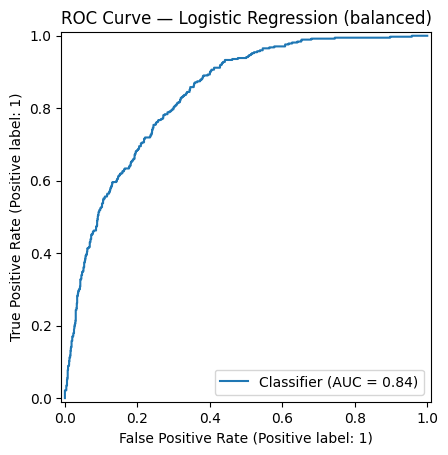

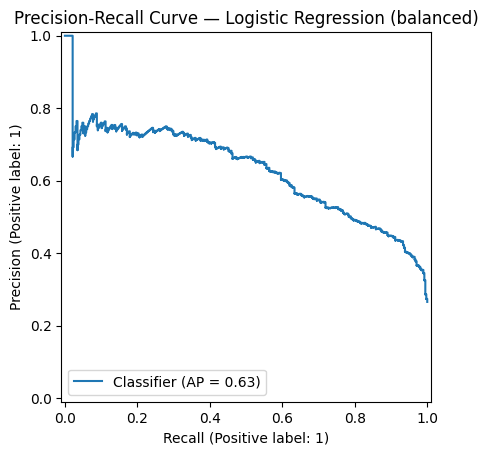

In [25]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
log_reg.fit(Xtr_lin, ytr)

yproba_lr = log_reg.predict_proba(Xte_lin)[:, 1]
evaluate_model("Logistic Regression (balanced)", yte, yproba_lr, threshold=0.5)


### Logistic Regression Results

The Logistic Regression model demonstrates strong baseline performance, achieving a ROC-AUC of 0.84 and a PR-AUC of 0.63. These results indicate good ranking ability and strong effectiveness in identifying churners within an imbalanced dataset.

At the default classification threshold of 0.5, the model achieves a recall of approximately 0.78 for churned customers, successfully identifying most at-risk users. Precision for churn is approximately 0.51, reflecting a reasonable tradeoff between false positives and missed churners.

Overall, the model provides a solid and interpretable baseline for churn prediction and serves as a reference point for more complex models.


### Tree-Based Model: Random Forest

Random Forest can capture non-linear relationships and interactions between features.  
We use `class_weight="balanced"` to help with churn imbalance.


=== Random Forest ===
ROC-AUC: 0.8408
PR-AUC : 0.6484
Threshold: 0.50

Confusion Matrix:
[[858 177]
 [130 244]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8684    0.8290    0.8482      1035
           1     0.5796    0.6524    0.6138       374

    accuracy                         0.7821      1409
   macro avg     0.7240    0.7407    0.7310      1409
weighted avg     0.7918    0.7821    0.7860      1409



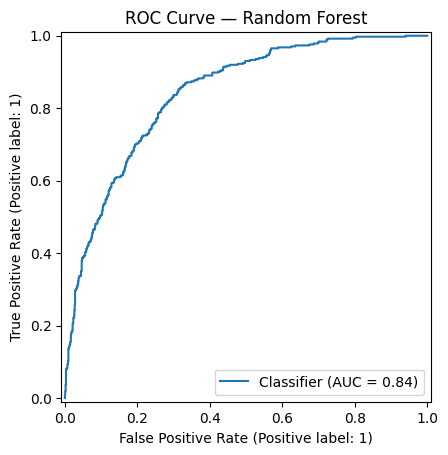

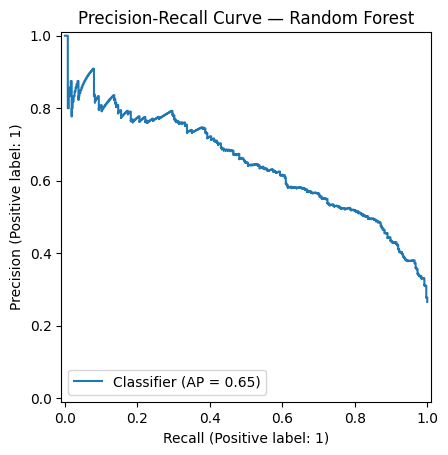

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced",
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1
)

rf.fit(Xtr_tree, ytr)

yproba_rf = rf.predict_proba(Xte_tree)[:, 1]
evaluate_model("Random Forest", yte, yproba_rf, threshold=0.5)


### Random Forest Results

The Random Forest model achieves a ROC-AUC of 0.84 and a PR-AUC of 0.65, slightly outperforming Logistic Regression in precision-recall performance. At the default threshold of 0.5, the model produces higher precision for churn predictions but lower recall compared to the baseline model.

This indicates that the Random Forest model is more conservative, identifying fewer churners but generating fewer false positives. The choice between models depends on business priorities, such as whether maximizing churn detection or minimizing unnecessary retention actions is more important.


### Threshold Tuning

The default threshold of 0.5 may not be optimal for churn.  
We test multiple thresholds and choose one that balances precision and recall.


In [27]:
def threshold_sweep(y_true, y_proba, thresholds=np.linspace(0.1, 0.9, 17)):
    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
        rows.append({
            "threshold": t,
            "precision_churn": report["1"]["precision"],
            "recall_churn": report["1"]["recall"],
            "f1_churn": report["1"]["f1-score"],
        })
    return pd.DataFrame(rows)

lr_sweep = threshold_sweep(yte, yproba_lr)
rf_sweep = threshold_sweep(yte, yproba_rf)

lr_sweep.sort_values("f1_churn", ascending=False).head(10)


,threshold,precision_churn,recall_churn,f1_churn
9,0.55,0.526415,0.745989,0.617257
8,0.50,0.507881,0.775401,0.613757
10,0.60,0.545073,0.695187,0.611046
7,0.45,0.483360,0.815508,0.606965
12,0.70,0.616022,0.596257,0.605978
6,0.40,0.467249,0.858289,0.605090
11,0.65,0.562212,0.652406,0.603960
5,0.35,0.447543,0.901070,0.598048
4,0.30,0.432298,0.930481,0.590331
13,0.75,0.664360,0.513369,0.579186


In [28]:
rf_sweep.sort_values("f1_churn", ascending=False).head(10)


,threshold,precision_churn,recall_churn,f1_churn
5,0.35,0.514530,0.804813,0.627737
4,0.30,0.491551,0.855615,0.624390
7,0.45,0.560768,0.703209,0.623962
6,0.40,0.529412,0.745989,0.619312
8,0.50,0.579572,0.652406,0.613836
3,0.25,0.463380,0.879679,0.607011
9,0.55,0.620112,0.593583,0.606557
2,0.20,0.429658,0.906417,0.582975
10,0.60,0.643333,0.516043,0.572700
1,0.15,0.399083,0.930481,0.558587


In [29]:
best_lr_t = lr_sweep.loc[lr_sweep["f1_churn"].idxmax(), "threshold"]
best_rf_t = rf_sweep.loc[rf_sweep["f1_churn"].idxmax(), "threshold"]

best_lr_t, best_rf_t


(np.float64(0.55), np.float64(0.35))

=== Logistic Regression (tuned threshold) ===
ROC-AUC: 0.8388
PR-AUC : 0.6284
Threshold: 0.55

Confusion Matrix:
[[784 251]
 [ 95 279]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8919    0.7575    0.8192      1035
           1     0.5264    0.7460    0.6173       374

    accuracy                         0.7544      1409
   macro avg     0.7092    0.7517    0.7182      1409
weighted avg     0.7949    0.7544    0.7656      1409



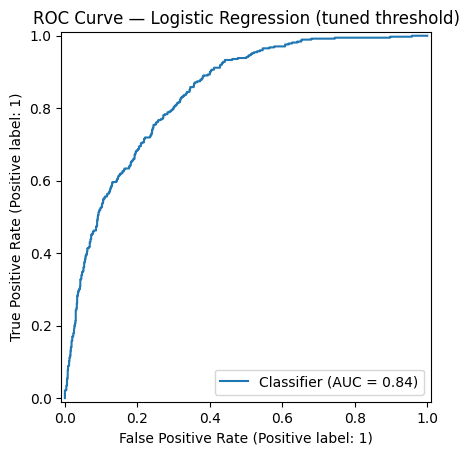

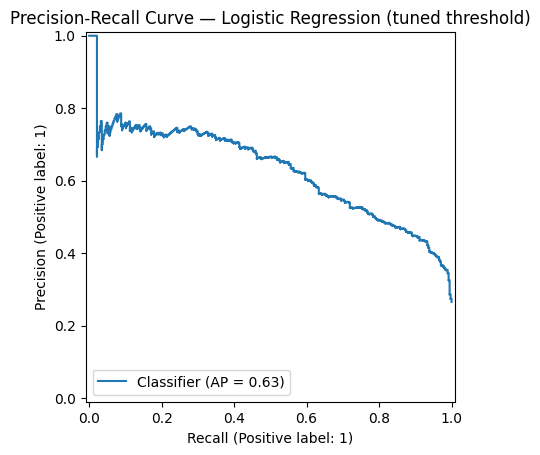

=== Random Forest (tuned threshold) ===
ROC-AUC: 0.8408
PR-AUC : 0.6484
Threshold: 0.35

Confusion Matrix:
[[751 284]
 [ 73 301]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9114    0.7256    0.8080      1035
           1     0.5145    0.8048    0.6277       374

    accuracy                         0.7466      1409
   macro avg     0.7130    0.7652    0.7178      1409
weighted avg     0.8061    0.7466    0.7601      1409



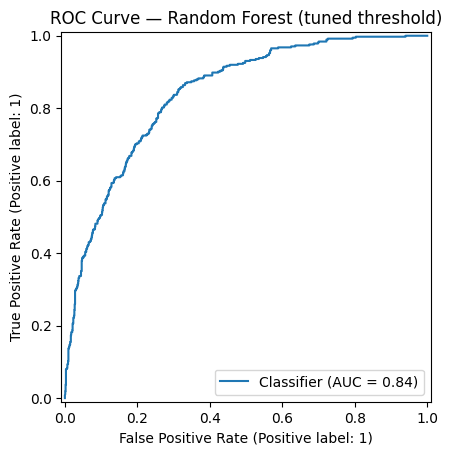

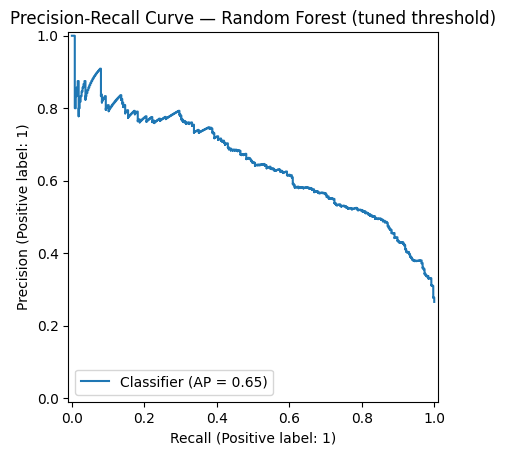

In [30]:
evaluate_model("Logistic Regression (tuned threshold)", yte, yproba_lr, threshold=float(best_lr_t))
evaluate_model("Random Forest (tuned threshold)", yte, yproba_rf, threshold=float(best_rf_t))


### Threshold Tuning — Logistic Regression

Threshold tuning was performed to adjust the balance between precision and recall for churn prediction. Increasing the threshold from 0.50 to 0.55 resulted in higher precision for churn predictions while maintaining a strong recall of approximately 0.75.

ROC-AUC and PR-AUC remained unchanged, as expected, since these metrics evaluate ranking performance across all thresholds. The selected threshold reflects a more conservative strategy that reduces false positives while still identifying the majority of churned customers.


### Random Forest Results After Threshold Tuning

Threshold tuning was applied to the Random Forest model to improve detection of churned customers. Lowering the classification threshold from 0.50 to 0.35 increased recall for churners while maintaining reasonable precision.

At the selected threshold, the model correctly identifies approximately 80% of churned customers, significantly reducing the number of missed churners compared to the default threshold. While this results in a higher number of false positives, this tradeoff is appropriate for churn prevention scenarios where failing to identify an at-risk customer is more costly than contacting a customer who ultimately does not churn.

ROC-AUC and PR-AUC values remain unchanged after threshold tuning, as these metrics evaluate ranking performance across all thresholds. The tuned Random Forest model demonstrates strong overall performance and is well-suited for retention-focused use cases.


### Final Model Selection

Both Logistic Regression and Random Forest models demonstrated strong performance, with similar ROC-AUC values around 0.84. Threshold tuning was applied to align predictions with a churn-prevention objective.

After tuning, the Random Forest model achieved the highest recall for churned customers (approximately 0.80) and the strongest PR-AUC (0.65), indicating superior performance in identifying at-risk customers within an imbalanced dataset.

A threshold of 0.35 was selected for the Random Forest model to prioritize churn detection while maintaining acceptable precision. This model is selected as the final model for churn prediction, as it best balances predictive performance and business objectives.


## 8. Feature Importance (Random Forest)

Feature importance helps identify which features contribute most to churn predictions.


In [31]:
importances = pd.Series(rf.feature_importances_, index=Xtr_tree.columns).sort_values(ascending=False)
importances.head(15)


tenure                            0.172467
TotalCharges                      0.161070
MonthlyCharges                    0.148512
Contract_Two year                 0.077778
InternetService_Fiber optic       0.067301
PaymentMethod_Electronic check    0.045952
Contract_One year                 0.036441
InternetService_No                0.030333
OnlineSecurity_Yes                0.026861
PaperlessBilling_Yes              0.026391
TechSupport_Yes                   0.022895
gender_Male                       0.020885
Partner_Yes                       0.019018
OnlineBackup_Yes                  0.018483
Dependents_Yes                    0.017554
dtype: float64

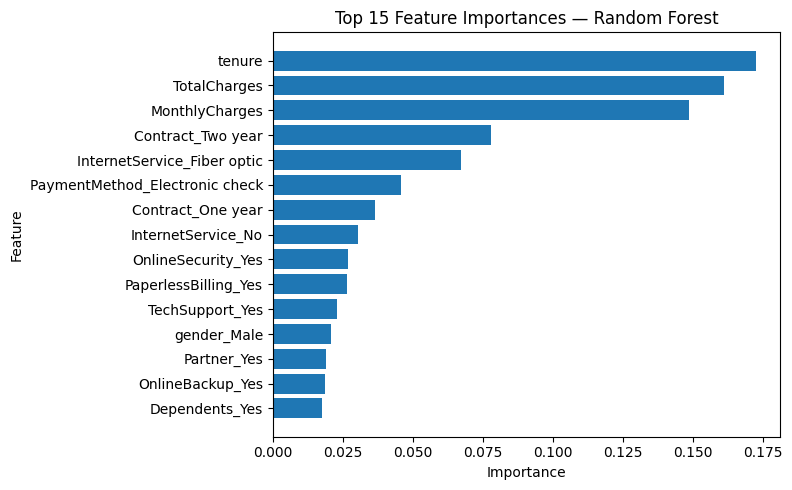

In [32]:
top_n = 15
imp_top = importances.head(top_n).sort_values()

plt.figure(figsize=(8,5))
plt.barh(imp_top.index, imp_top.values)
plt.title(f"Top {top_n} Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Feature Importance Interpretation

The Random Forest model identifies customer tenure, total charges, and monthly charges as the most influential features for churn prediction. These variables collectively capture customer lifetime behavior and pricing exposure.

Contract length also plays a significant role, with longer-term contracts strongly associated with reduced churn risk. Internet service type and payment method contribute additional predictive power, reflecting differences in pricing tiers and billing behavior.

Add-on services such as online security and tech support show moderate importance, suggesting that customers with more bundled services tend to be more stable. Demographic features appear less influential, indicating that churn is driven primarily by behavioral and contractual factors rather than personal attributes.


## 9. Logistic Regression Coefficients (Interpretability)

Positive coefficients increase churn probability, while negative coefficients reduce churn probability.  
Because features were scaled and one-hot encoded, coefficients are comparable for numerical features but should still be interpreted with care.


In [33]:
coef = pd.Series(log_reg.coef_[0], index=Xtr_lin.columns).sort_values()
coef.head(15), coef.tail(15)


(Contract_Two year                       -1.408532
 InternetService_No                      -1.011684
 tenure                                  -0.757051
 Contract_One year                       -0.724503
 PhoneService_Yes                        -0.362915
 OnlineSecurity_Yes                      -0.352915
 TechSupport_Yes                         -0.282966
 Dependents_Yes                          -0.239849
 MonthlyCharges                          -0.213262
 MultipleLines_No phone service          -0.096094
 OnlineBackup_Yes                        -0.078983
 PaymentMethod_Credit card (automatic)   -0.007861
 Partner_Yes                              0.014419
 DeviceProtection_Yes                     0.031087
 gender_Male                              0.038389
 dtype: float64,
 MonthlyCharges                          -0.213262
 MultipleLines_No phone service          -0.096094
 OnlineBackup_Yes                        -0.078983
 PaymentMethod_Credit card (automatic)   -0.007861
 Partner_Yes  

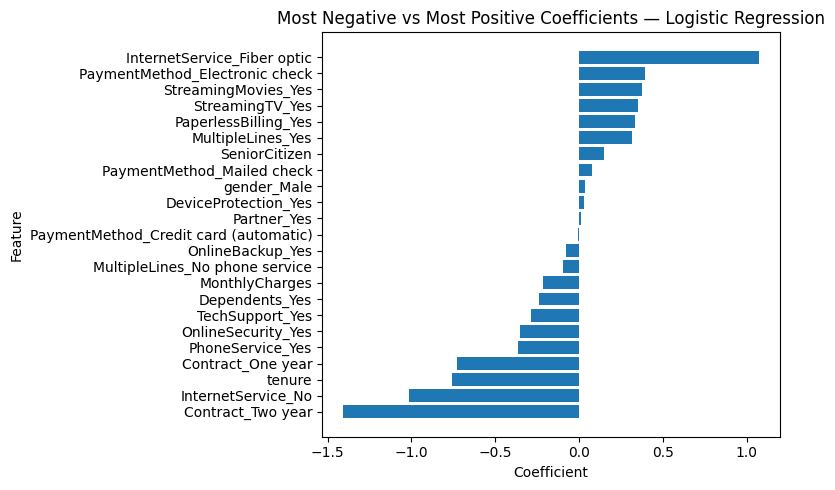

In [34]:
top_n = 12
coef_top = pd.concat([coef.head(top_n), coef.tail(top_n)])

plt.figure(figsize=(8,5))
plt.barh(coef_top.index, coef_top.values)
plt.title("Most Negative vs Most Positive Coefficients — Logistic Regression")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Logistic Regression Coefficient Interpretation

The Logistic Regression model provides directional insight into churn risk. Positive coefficients indicate features associated with increased churn probability, while negative coefficients indicate features that reduce churn risk.

The strongest churn risk factors include fiber optic internet service, electronic check payment method, streaming services, and paperless billing. These features are associated with higher-cost or higher-complexity service profiles.

The strongest protective factors against churn are long-term contracts, longer tenure, and the use of security or support services. In particular, two-year contracts exhibit the largest negative coefficient, highlighting the stabilizing effect of long-term commitments.

Overall, the coefficients suggest that churn is driven primarily by pricing exposure, payment friction, and service complexity, while customer longevity and contractual commitment strongly reduce churn risk.


## 10. Final Model Summary

This project evaluated two model families for customer churn prediction: Logistic Regression and Random Forest. Both models demonstrated strong ranking performance, with ROC-AUC values around 0.84, indicating good separation between churned and non-churned customers.

Logistic Regression provided a clear and interpretable baseline, highlighting the importance of customer tenure, contract length, pricing, and payment method. Threshold tuning was applied to adjust the precision–recall tradeoff, resulting in a balanced model that captures the majority of churned customers while limiting unnecessary false positives.

The Random Forest model achieved the strongest overall performance after threshold tuning. With a selected threshold of 0.35, the model identified approximately 80% of churned customers and achieved the highest PR-AUC, making it well-suited for churn prevention scenarios where recall is prioritized. Feature importance analysis confirmed that customer lifetime behavior, contract commitment, and pricing structure are the primary drivers of churn.

Based on these results, the tuned Random Forest model was selected as the final model for churn prediction. Logistic Regression remains a valuable complementary model for interpretability and insight generation. Together, these models provide both predictive strength and actionable understanding of customer churn behavior.
